# scvi-tools workflow
## setup

In [14]:
import os
import tempfile

import scanpy as sc
import scvi
import seaborn as sns
import torch
import matplotlib.pyplot as plt

In [3]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

Seed set to 0


Last run with scvi-tools version: 1.4.2


In [4]:
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")
save_dir = tempfile.TemporaryDirectory()

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

## load and prepare data

In [5]:
adata = scvi.data.heart_cell_atlas_subsampled(save_path=save_dir.name)
adata

INFO     Downloading file at /var/folders/rj/58krw3q53619qt2rbck9wq740000gn/T/tmpd4ayllye/hca_subsampled_20k.h5ad  
Downloading...: 100%|██████████| 65714/65714.0 [00:08<00:00, 7824.28it/s] 


AnnData object with n_obs × n_vars = 18641 × 26662
    obs: 'NRP', 'age_group', 'cell_source', 'cell_type', 'donor', 'gender', 'n_counts', 'n_genes', 'percent_mito', 'percent_ribo', 'region', 'sample', 'scrublet_score', 'source', 'type', 'version', 'cell_states', 'Used'
    var: 'gene_ids-Harvard-Nuclei', 'feature_types-Harvard-Nuclei', 'gene_ids-Sanger-Nuclei', 'feature_types-Sanger-Nuclei', 'gene_ids-Sanger-Cells', 'feature_types-Sanger-Cells', 'gene_ids-Sanger-CD45', 'feature_types-Sanger-CD45', 'n_counts'
    uns: 'cell_type_colors'

In [6]:
sc.pp.filter_genes(adata, min_counts=3)

In [7]:
adata.layers["counts"] = adata.X.copy()  # preserve counts
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata  # freeze the state in `.raw`

In [8]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=1200,
    subset=True,
    layer="counts",
    flavor="seurat_v3",
    batch_key="cell_source",
)

In [9]:
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    categorical_covariate_keys=["cell_source", "donor"],
    continuous_covariate_keys=["percent_mito", "percent_ribo"],
)

## create and train model

In [10]:
model = scvi.model.SCVI(adata)
model

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

In [11]:
model.train(train_size=0.8, check_val_every_n_epoch=1)

/Users/otodreas/Desktop/Work/Nygen/Interview/.venv/lib/python3.12/site-packages/scvi/train/_trainrunner.py:98: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/otodreas/Desktop/Work/Nygen/Interview/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/otodreas/Desktop/Work/Nygen/Interview/.venv/lib/python3.12/site-pa

Epoch 400/400: 100%|██████████| 400/400 [07:51<00:00,  1.17s/it, v_num=1, train_loss=282]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [07:51<00:00,  1.18s/it, v_num=1, train_loss=282]


## save and load
the purpose of saving is to "freeze" the ANN weights, biases, and parameters used to initialize the model

In [ ]:
model_dir = os.path.join(save_dir.name, "scvi_model")
model.save(model_dir, overwrite=True)
# Load the model
# model = scvi.model.SCVI.load(model_dir, adata=adata)

INFO     File /var/folders/rj/58krw3q53619qt2rbck9wq740000gn/T/tmpd4ayllye/scvi_model/model.pt already downloaded  


/Users/otodreas/Desktop/Work/Nygen/Interview/.venv/lib/python3.12/site-packages/scvi/model/base/_base_model.py:862: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  _, _, device = parse_device_args(


## generate loss curves
access the losses in the `model.history` object and plot

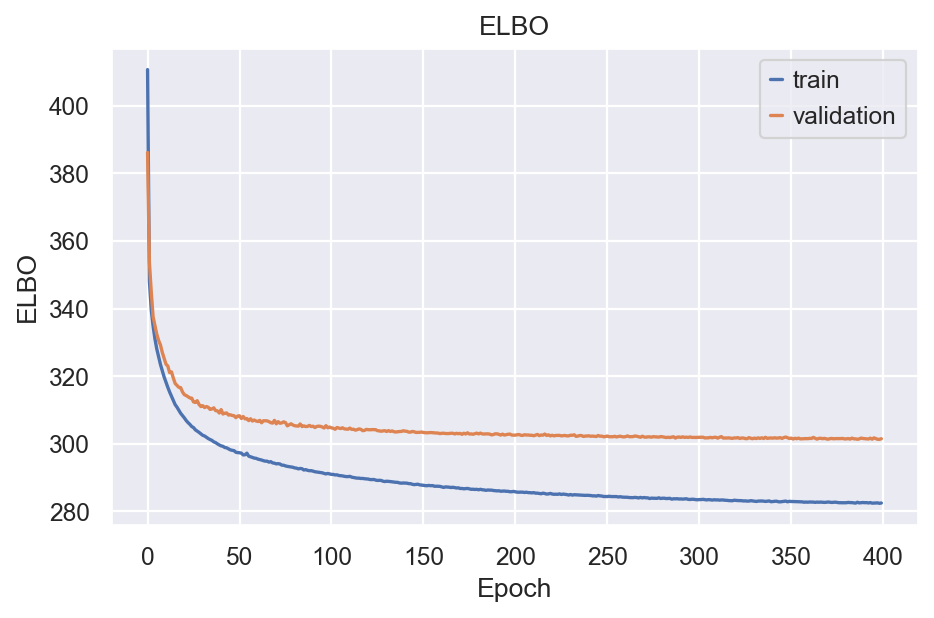

In [15]:
hist = model.history

def plot_metric(train_key, val_key, title, ylabel):
    plt.figure(figsize=(6, 4))
    plt.plot(hist[train_key], label="train")
    plt.plot(hist[val_key], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Negative ELBO (Evidence lower bound)
if "elbo_train" in hist:
    plot_metric("elbo_train", "elbo_validation", "ELBO", "ELBO")